# Q-learning no FrozenLake: um agente que aprende por tentativa e erro

Neste notebook vamos treinar um agente para atravessar um lago congelado sem cair nos buracos. Ninguém vai dizer ao agente qual é o caminho certo: ele só recebe **recompensa 1** quando chega ao objetivo e **0** em qualquer outro caso. A partir disso, ele aprende sozinho a melhor estratégia.

**O que vamos ver:**
1. O ambiente e seus termos (estado, ação, recompensa, episódio)
2. A tabela Q, o "caderno de anotações" do agente
3. O treinamento com Q-learning
4. Como avaliar o agente treinado
5. Onde o método começa a falhar

In [1]:
# Se estiver no Google Colab ou em um ambiente novo, descomente a linha abaixo:
# !pip install gymnasium numpy matplotlib

import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Registramos as versões para que o resultado seja reproduzível
print("gymnasium:", gym.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)

gymnasium: 1.3.0
numpy: 2.4.4
matplotlib: 3.10.8


## 1. O ambiente

O **FrozenLake** é uma grade 4×4. O agente começa em `S` (start) e precisa chegar em `G` (goal). `F` é gelo firme e `H` é buraco (hole): cair nele encerra a tentativa.

```
S F F F
F H F H
F F F H
H F F G
```

Alguns termos que vamos usar o tempo todo:
- **Estado**: onde o agente está. Aqui são 16 estados, numerados de 0 a 15.
- **Ação**: o que o agente pode fazer. São 4: esquerda (0), baixo (1), direita (2), cima (3).
- **Recompensa**: o número que o ambiente devolve depois de cada ação.
- **Episódio**: uma tentativa completa, do início até cair num buraco ou chegar ao objetivo.

Começamos com o gelo **não escorregadio** (`is_slippery=False`): cada ação faz exatamente o que promete. Mais adiante ligamos o escorregão.

In [2]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

n_estados = env.observation_space.n   # 16
n_acoes = env.action_space.n          # 4
print(f"Estados: {n_estados}, ações: {n_acoes}")

Estados: 16, ações: 4


Antes de aprender qualquer coisa, vejamos como se sai um agente que escolhe ações **ao acaso**. Esse é o nosso ponto de comparação.

In [3]:
def taxa_de_sucesso(env, escolher_acao, episodios=1000, seed=0):
    """Roda vários episódios e devolve a fração em que o agente chegou ao objetivo."""
    sucessos = 0
    for ep in range(episodios):
        estado, _ = env.reset(seed=seed + ep)
        terminou = truncou = False
        while not (terminou or truncou):
            acao = escolher_acao(estado)
            estado, recompensa, terminou, truncou, _ = env.step(acao)
        sucessos += recompensa  # recompensa final é 1 só se chegou em G
    return sucessos / episodios

aleatorio = lambda estado: env.action_space.sample()
print(f"Agente aleatório: {taxa_de_sucesso(env, aleatorio):.1%} de sucesso")

Agente aleatório: 1.0% de sucesso


## 2. A tabela Q

O agente guarda uma **tabela Q** com uma linha por estado e uma coluna por ação. Cada célula `Q[estado, ação]` responde à pergunta: *"se eu estiver aqui e fizer isto, quanta recompensa espero acumular daqui em diante?"*

No começo o agente não sabe nada, então a tabela começa zerada.

In [4]:
Q = np.zeros((n_estados, n_acoes))
Q[:4]  # primeiras 4 linhas: tudo zero

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3. Treinando com Q-learning

A cada passo o agente faz três coisas:

1. **Escolhe uma ação.** Na maior parte das vezes escolhe a melhor que conhece (*explorar o que já sabe*), mas com probabilidade ε (epsilon) escolhe uma ação aleatória (*explorar o desconhecido*). Sem essa aleatoriedade, ele repetiria para sempre o primeiro caminho que encontrou.
2. **Observa** o novo estado e a recompensa.
3. **Atualiza** a tabela: puxa o valor antigo um pouco na direção de *"recompensa que acabei de receber + o melhor valor que espero a partir do próximo estado"*.

> **Aprofundamento: a regra de atualização**
>
> $$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$
>
> - $\alpha$ (taxa de aprendizado): quanto confiamos na nova experiência em relação ao que já sabíamos.
> - $\gamma$ (fator de desconto): quanto valorizamos recompensas futuras. Perto de 1 = agente paciente.
> - O termo entre colchetes é o **erro de diferença temporal**: a diferença entre o que esperávamos e o que acabamos de observar.

In [5]:
def treinar_q_learning(env, episodios=2000, alpha=0.1, gamma=0.99,
                       eps_inicio=1.0, eps_fim=0.05, seed=42):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    recompensas = []

    for ep in range(episodios):
        # epsilon cai linearmente: muita exploração no começo, pouca no fim
        eps = max(eps_fim, eps_inicio - (eps_inicio - eps_fim) * ep / (0.8 * episodios))
        estado, _ = env.reset(seed=seed + ep)
        terminou = truncou = False

        while not (terminou or truncou):
            # 1. Escolher ação (epsilon-greedy)
            if rng.random() < eps:
                acao = env.action_space.sample()
            else:
                # desempate aleatório entre ações com o mesmo valor
                melhores = np.flatnonzero(Q[estado] == Q[estado].max())
                acao = rng.choice(melhores)

            # 2. Agir e observar
            novo_estado, recompensa, terminou, truncou, _ = env.step(acao)

            # 3. Atualizar a tabela (se o episódio terminou, não há futuro a considerar)
            alvo = recompensa + gamma * np.max(Q[novo_estado]) * (not terminou)
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])

            estado = novo_estado

        recompensas.append(recompensa)

    return Q, np.array(recompensas)

env.action_space.seed(42)
Q, recompensas = treinar_q_learning(env)

Como a recompensa é 0 ou 1, a curva crua é ruidosa. Por isso plotamos a **média móvel** de 100 episódios: ela mostra a fração de sucessos recentes.

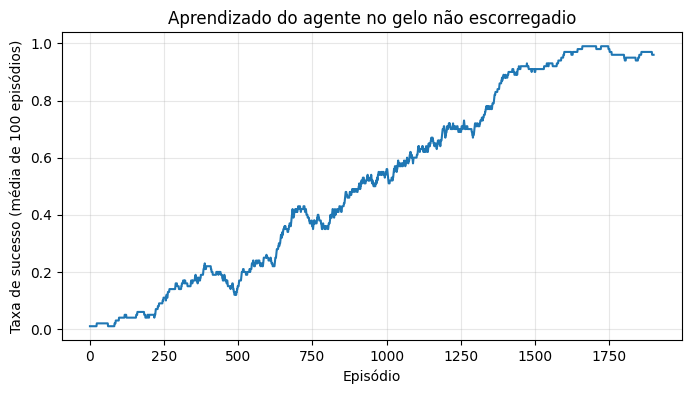

In [6]:
def media_movel(x, janela=100):
    return np.convolve(x, np.ones(janela) / janela, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(media_movel(recompensas))
plt.xlabel("Episódio")
plt.ylabel("Taxa de sucesso (média de 100 episódios)")
plt.title("Aprendizado do agente no gelo não escorregadio")
plt.grid(alpha=0.3)
plt.show()

## 4. Avaliando o agente treinado

Agora desligamos a exploração: o agente sempre escolhe a ação de maior valor Q. Chamamos isso de **política gulosa** (*greedy*).

In [7]:
guloso = lambda estado: int(np.argmax(Q[estado]))
print(f"Agente treinado: {taxa_de_sucesso(env, guloso):.1%} de sucesso")

Agente treinado: 100.0% de sucesso


Uma forma visual de ler a tabela Q é desenhar, em cada casa do mapa, a seta da melhor ação.

In [8]:
setas = np.array(["←", "↓", "→", "↑"])
mapa = env.unwrapped.desc.astype(str)

politica = setas[np.argmax(Q, axis=1)].reshape(4, 4)
for i in range(4):
    linha = []
    for j in range(4):
        casa = mapa[i, j]
        linha.append(casa if casa in "HG" else politica[i, j])
    print(" ".join(linha))

↓ ← ↓ ←
↓ H ↓ H
→ → ↓ H
H → → G


## 5. Onde o método começa a falhar

### 5.1 Quando o mundo é incerto

Vamos ligar o escorregão (`is_slippery=True`). Agora cada ação só vai para a direção pretendida em 1/3 das vezes; nas outras, o agente escorrega para os lados. O mesmo algoritmo precisa de muito mais episódios, e nem a política ótima chega a 100%.

Agente treinado (escorregadio): 75.1% de sucesso


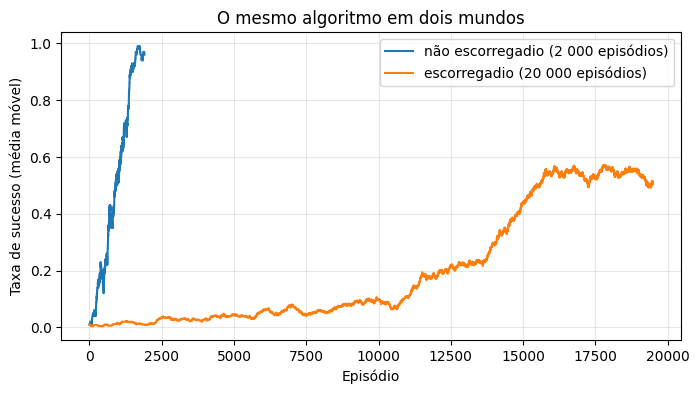

In [9]:
env_escorregadio = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
env_escorregadio.action_space.seed(42)

Q_esc, rec_esc = treinar_q_learning(env_escorregadio, episodios=20000, alpha=0.05)

guloso_esc = lambda estado: int(np.argmax(Q_esc[estado]))
print(f"Agente treinado (escorregadio): {taxa_de_sucesso(env_escorregadio, guloso_esc):.1%} de sucesso")

plt.figure(figsize=(8, 4))
plt.plot(media_movel(recompensas), label="não escorregadio (2 000 episódios)")
plt.plot(media_movel(rec_esc, 500), label="escorregadio (20 000 episódios)")
plt.xlabel("Episódio")
plt.ylabel("Taxa de sucesso (média móvel)")
plt.title("O mesmo algoritmo em dois mundos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.2 Quando há estados demais

A tabela Q tem uma linha por estado. No FrozenLake 4×4 são 16. Num tabuleiro de xadrez, o número de posições possíveis é astronomicamente maior do que qualquer memória comporta, e numa imagem de videogame cada combinação de pixels seria um estado. É aqui que o Q-learning tabular para de funcionar e entram métodos que **aproximam** a tabela com uma rede neural, como o **Deep Q-Network (DQN)**.

### 5.3 Outros cuidados
- **Exploração vs. aproveitamento:** com ε baixo demais cedo demais, o agente se contenta com um caminho ruim.
- **Recompensa esparsa:** aqui o agente só recebe sinal no final. No começo do treino ele vaga sem nenhuma pista, o que torna o aprendizado lento.
- **Hiperparâmetros:** α, γ e o ritmo de queda de ε mudam bastante o resultado. Experimente alterá-los e rodar de novo.

## Para experimentar
- Troque `map_name="4x4"` por `"8x8"` e veja quantos episódios o agente precisa.
- Mude `gamma` para 0.5. O que acontece com a política?
- Troque a atualização por SARSA: em vez de `np.max(Q[novo_estado])`, use o valor da ação que o agente **realmente** vai tomar no próximo passo.